In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
import matplotlib.patheffects as pe

from clim_functions import compute_AR_from_Q, collect_tracking_R, tracking_kdtree, day_plot


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


Cleaning.
1. Valid data for both inner- and outer-core data i.e. .dropna()
2. Cyclonicity must match
3. Reasonable values i.e. (Rc <= 300, |w| <= 1e-3)
4. detQ = 1
5. DOPPIO center must be reasonably close to nencioli center

In [3]:
fp = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_DOPPIO_SEACOFS_26yr.pkl'
df_doppio = pd.read_pickle(fp)
df_doppio['w'] *= 1e-3; #df_doppio['Omega0'] *= 1e-3; df_doppio['Omega'] *= 1e-3
df_doppio


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414944,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056
414945,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338
414946,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871
414947,10650,10641,157.0,34.0,CE,156.552258,33.561023,-0.000006,"[[1.1638016290142272, 0.659198284050232], [0.6...",-0.002711,-0.003349,95.216962,15.183481,33.510155


In [4]:
# --- 1. Drop only required columns ---
df_clean1 = df_doppio.dropna().copy()

print(f'1. Removed {len(df_doppio) - len(df_clean1)} eddy-days')

# --- 2. Cyclonicity match ---
nenc_cyc = np.where(df_clean1['nCyc'].values == 'AE', 1, -1)
doppio_cyc = np.sign(df_clean1['w'].values)

mask = (nenc_cyc == doppio_cyc)
df_clean2 = df_clean1.loc[mask].copy()

print(f'2. Removed {len(df_clean1) - len(df_clean2)} eddy-days')

# --- 3. Extract Q ONCE ---
df_clean2['AR'] = compute_AR_from_Q(np.stack(df_clean2['Q'].values))

# --- detQ (vectorised) ---
detQ = df_clean2['Q'].apply(lambda Q: Q[0,0]*Q[1,1] - Q[1,0]**2)

# --- masks ---
realistic_mask = (
    (df_clean2['Rc'].values < 300)
    & (np.abs(df_clean2['w'].values) < 1e-3)
    & (np.abs(df_clean2['AR']) < 8)
)

boundary_mask = (
    (df_clean2['xc'].values > 0)
    & (df_clean2['xc'].values < X_grid.max())
    & (df_clean2['yc'].values > 0)
    & (df_clean2['yc'].values < Y_grid.max())
)

det_mask = np.isclose(detQ, 1, atol=1e-5)

# --- center error ---
err = np.hypot(
    df_clean2['xc'].values - df_clean2['nxc'].values,
    df_clean2['yc'].values - df_clean2['nyc'].values
)
center_mask = err < 20

# --- combine everything at once (faster & cleaner) ---
final_mask = realistic_mask & boundary_mask & det_mask & center_mask

df_clean = df_clean2.loc[final_mask].copy().reset_index(drop=True)

print(f'Total removed: {len(df_clean2) - len(df_clean)} eddy-days')


1. Removed 96751 eddy-days
2. Removed 756 eddy-days
Total removed: 36584 eddy-days


,Day,fnumber,nxc,nyc,nCyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876


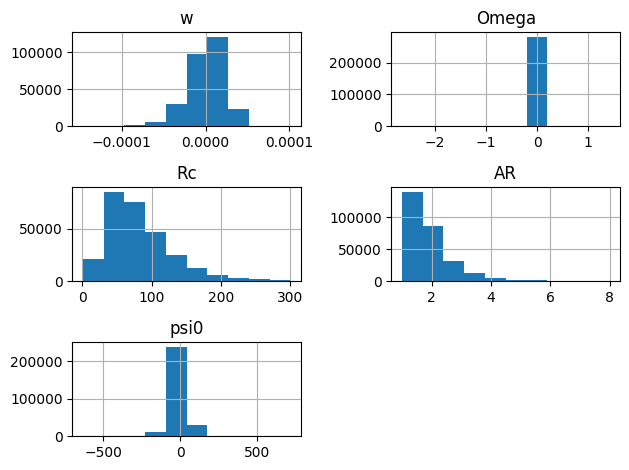

In [5]:
df_clean.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()
df_clean.head()


Tracking

In [7]:
df_data = df_clean.copy()
df_data = df_data.rename(columns={'nCyc': 'Cyc'})
df_data['eddy_idx'] = df_data.groupby('Day').cumcount()
df_data


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389,0
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935,1
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162,2
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757,3
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280853,10650,10641,860.0,180.0,CE,859.194829,180.306373,-0.000007,"[[0.6614053902780358, 0.4389834439185585], [0....",-0.003002,-0.003210,82.764188,10.994798,59.843014,1.952544,16
280854,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056,1.500011,17
280855,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338,3.177834,18
280856,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871,1.636702,19


Optimal R = 1

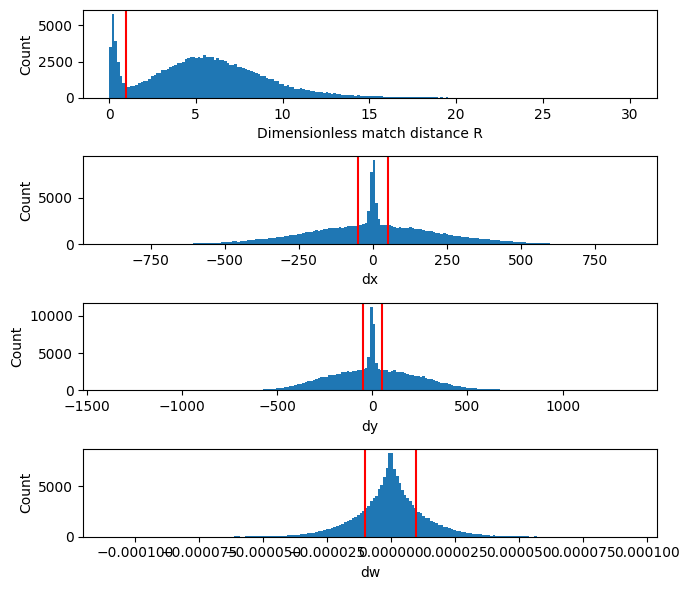

In [15]:
df = df_data[df_data.Day <= df_data.Day.min() + 1000]
df_R = collect_tracking_R(
    df,
    L_SCALE=50,
    W_SCALE=1e-5,
    LOOKBACK=4
)

fig, axes = plt.subplots(4, 1, figsize=(7, 6), sharex=False)

# R
axes[0].hist(df_R['R'], bins=200)
axes[0].axvline(1, color='r')
axes[0].set_xlabel('Dimensionless match distance R')
axes[0].set_ylabel('Count')

# dx
axes[1].hist(df_R['dx'], bins=200)
axes[1].axvline(-50, color='r')
axes[1].axvline(50, color='r')
axes[1].set_xlabel('dx')
axes[1].set_ylabel('Count')

# dy
axes[2].hist(df_R['dy'], bins=200)
axes[2].axvline(-50, color='r')
axes[2].axvline(50, color='r')
axes[2].set_xlabel('dy')
axes[2].set_ylabel('Count')

# dw
axes[3].hist(df_R['dw'], bins=200)
axes[3].axvline(-1e-5, color='r')
axes[3].axvline(1e-5, color='r')
axes[3].set_xlabel('dw')
axes[3].set_ylabel('Count')

plt.tight_layout()
plt.show()


Tracking

In [21]:
df = df_data.copy()#[df_data.Day <= df_data.Day.min() + 200]

start_ID = np.arange(len(df[df.Day==df.Day.min()]))
next_num = np.max(start_ID) + 1

df_tracked = tracking_kdtree(
    df,
    start_ID=start_ID,
    next_num=next_num,
    L_SCALE=50,
    W_SCALE=1e-5,
    R_THRESH=1, 
    LOOKBACK=4
)


Day 1600, elapsed: 17.78s
Day 1800, elapsed: 53.29s
Day 2000, elapsed: 81.30s
Day 2200, elapsed: 113.15s
Day 2400, elapsed: 139.21s
Day 2600, elapsed: 170.54s
Day 2800, elapsed: 199.74s
Day 3000, elapsed: 229.25s
Day 3200, elapsed: 257.09s
Day 3400, elapsed: 282.25s
Day 3600, elapsed: 312.79s
Day 3800, elapsed: 338.99s
Day 4000, elapsed: 371.68s
Day 4200, elapsed: 399.27s
Day 4400, elapsed: 432.37s
Day 4600, elapsed: 459.58s
Day 4800, elapsed: 491.92s
Day 5000, elapsed: 523.01s
Day 5200, elapsed: 555.24s
Day 5400, elapsed: 588.07s
Day 5600, elapsed: 616.26s
Day 5800, elapsed: 649.08s
Day 6000, elapsed: 675.74s
Day 6200, elapsed: 714.68s
Day 6400, elapsed: 744.33s
Day 6600, elapsed: 778.36s
Day 6800, elapsed: 811.84s
Day 7000, elapsed: 846.96s
Day 7200, elapsed: 878.04s
Day 7400, elapsed: 906.16s
Day 7600, elapsed: 935.42s
Day 7800, elapsed: 962.12s
Day 8000, elapsed: 997.61s
Day 8200, elapsed: 1025.29s
Day 8400, elapsed: 1061.38s
Day 8600, elapsed: 1086.73s
Day 8800, elapsed: 1120.43s


In [22]:
df_tracked


,Day,fnumber,nxc,nyc,Cyc,xc,yc,w,Q,Omega0,Omega,Rc,psi0,R,AR,eddy_idx,Eddy,next_num
0,1462,1461,830.0,1515.0,AE,829.866281,1515.784745,0.000015,"[[0.6818813511835662, -0.01769448655641243], [...",0.006939,0.008165,97.033130,-38.436614,43.683507,1.467389,0,0,67099
1,1462,1461,358.0,1408.0,AE,357.716018,1407.297048,0.000029,"[[1.172910762121831, -0.5171323359074603], [-0...",0.012814,0.010725,87.972813,-41.501314,59.972382,1.645935,1,1,67099
2,1462,1461,928.0,1356.0,CE,929.039452,1356.121406,-0.000010,"[[0.6394227429140328, -0.36905411384618786], [...",-0.004169,-0.006521,113.963003,42.344780,74.600410,1.886162,2,2,67099
3,1462,1461,506.0,1354.0,CE,505.545197,1353.764885,-0.000030,"[[1.0195167656782433, -0.20828542587929186], [...",-0.014654,-0.012482,104.868137,68.634490,62.850374,1.229757,3,3,67099
4,1462,1461,754.0,1285.0,AE,754.096128,1284.807711,0.000021,"[[1.1420914556654878, -0.3819244877484292], [-...",0.009650,0.007811,104.502082,-42.648453,64.676066,1.460876,4,4,67099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280853,10650,10641,860.0,180.0,CE,859.194829,180.306373,-0.000007,"[[0.6614053902780358, 0.4389834439185585], [0....",-0.003002,-0.003210,82.764188,10.994798,59.843014,1.952544,16,67042,67099
280854,10650,10641,349.0,158.0,AE,348.639821,156.731941,0.000030,"[[1.4645774777137426, -0.1681457560425603], [-...",0.013843,0.010961,118.891449,-77.470619,43.106056,1.500011,17,67082,67099
280855,10650,10641,973.0,126.0,CE,981.263303,128.903719,-0.000003,"[[0.3331432297976212, 0.22917891709183946], [0...",-0.000959,-0.001517,55.056225,2.299476,24.775338,3.177834,18,67083,67099
280856,10650,10641,805.0,95.0,AE,805.224646,95.090287,0.000010,"[[1.458787846536923, 0.38837617534635543], [0....",0.004449,0.005426,61.560240,-10.280739,45.893871,1.636702,19,67038,67099


In [25]:
path = '/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tracked.pkl'
df_tracked.to_pickle(path)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


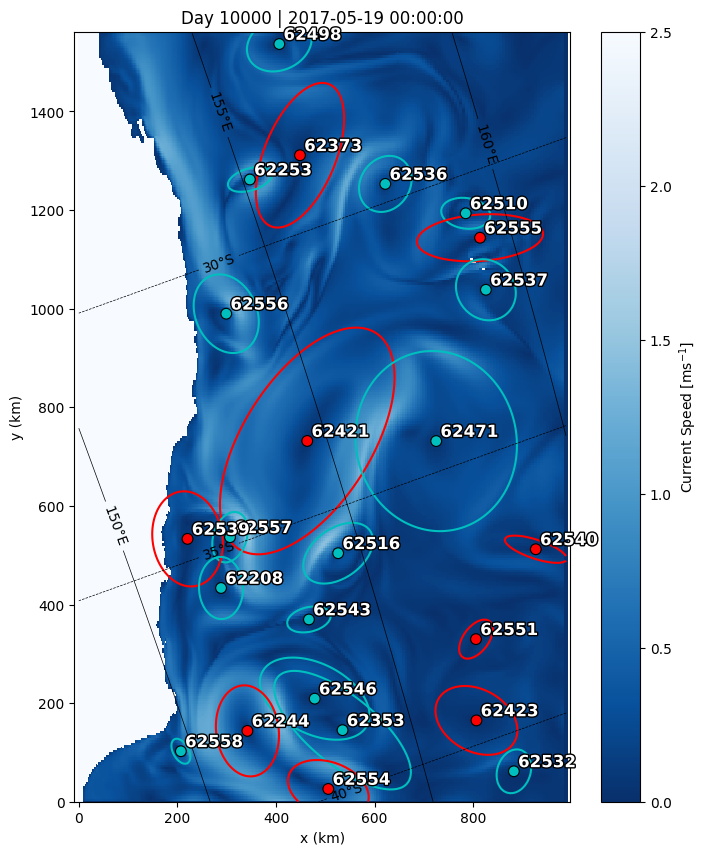

In [23]:
day_plot(10000, df_tracked)
